# Visualizing Wyvern Data Interactively with HyperCoast

[![image](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/opengeos/HyperCoast/blob/main/docs/examples/tanager.ipynb)


This notebook demonstrates how to visualize the [Wyvern hyperspectral data](https://www.planet.com/data/stac/browser/tanager-core-imagery/catalog.json) interactively with HyperCoast. 




## Install packages

Uncomment the following line to install the packages.

In [ ]:
%load_ext autoreload
%autoreload 2
import os,sys

# %pip install hypercoast

## Import libraries

In [ ]:
import hypercoast
import importlib
importlib.reload(hypercoast)

## Find Wyvern data

Browse the Wyvern data on the [Wyvern Open Data browser](https://wyvern.space/open-data/). Find the data you want to visualize.

For example, we want to visualize the data of the [coastal water bodies in Moloka'i](https://wyvern-prod-public-open-data-program.s3.ca-central-1.amazonaws.com/wyvern_dragonette-003_20250508T203730_3cb1306b/wyvern_dragonette-003_20250508T203730_3cb1306b.tiff).
Click on the "Copy URL" button to get the direct URL of the data.



## Download Wyvern data

Once you have the URL of the data, you can download the data using the following code. Note that the dataset can be around 5 GB, and may take some time to download. 

In [3]:
url = "https://wyvern-prod-public-open-data-program.s3.ca-central-1.amazonaws.com/wyvern_dragonette-003_20250508T203730_3cb1306b/wyvern_dragonette-003_20250508T203730_3cb1306b.tiff"

In [ ]:
file_path = hypercoast.download_file(url)

In [ ]:
file_path = # <local file path if file has already been downloaded>

## Read Wyvern data

We can read the Wyvern data using the `read_wyvern` function. It will return a `xarray.Dataset` object. The `toa_radiance` variable is the top of atmosphere radiance. It has 31 spectral bands. Note that the dataset is not gridded. We will need to interpolate the data to a regular grid for visualization on an interactive map.

In [6]:
dataset = hypercoast.read_wyvern(file_path)
dataset

<xarray.Dataset> Size: 8GB
Dimensions:       (wavelength: 31, y: 9662, x: 5759)
Coordinates:
  * wavelength    (wavelength) float64 248B 445.0 464.0 480.0 ... 849.0 869.0
    fwhm          (wavelength) float64 248B 15.6 16.2 16.8 ... 29.1 29.7 30.4
    latitude      (y, x) float64 445MB 21.22 21.22 21.22 ... 20.79 20.79 20.79
    longitude     (y, x) float64 445MB -157.2 -157.2 -157.2 ... -156.9 -156.9
Dimensions without coordinates: y, x
Data variables:
    toa_radiance  (wavelength, y, x) float32 7GB -9.999e+03 ... -9.999e+03
Attributes:
    source:     Wyvern COG
    stac_item:  https://wyvern-prod-public-open-data-program.s3.ca-central-1....

## Visualize Wyvern data

Let's visualize the Wyvern data on an interactive map. Specify the bands to visualize. You can visualize the data in the spectral space or the RGB space.

In [7]:
m = hypercoast.Map()
m.add_wyvern(dataset, bands=[22, 16, 8], vmin=0, vmax=120, layer_name="Wyvern")
m.add("spectral")

Band 734.0 has been spatially downsampled by a factor of 8.
Band 669.0 has been spatially downsampled by a factor of 8.
Band 550.0 has been spatially downsampled by a factor of 8.


In [8]:
m


Map(center=[21.0062845, -157.057984], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_titl…

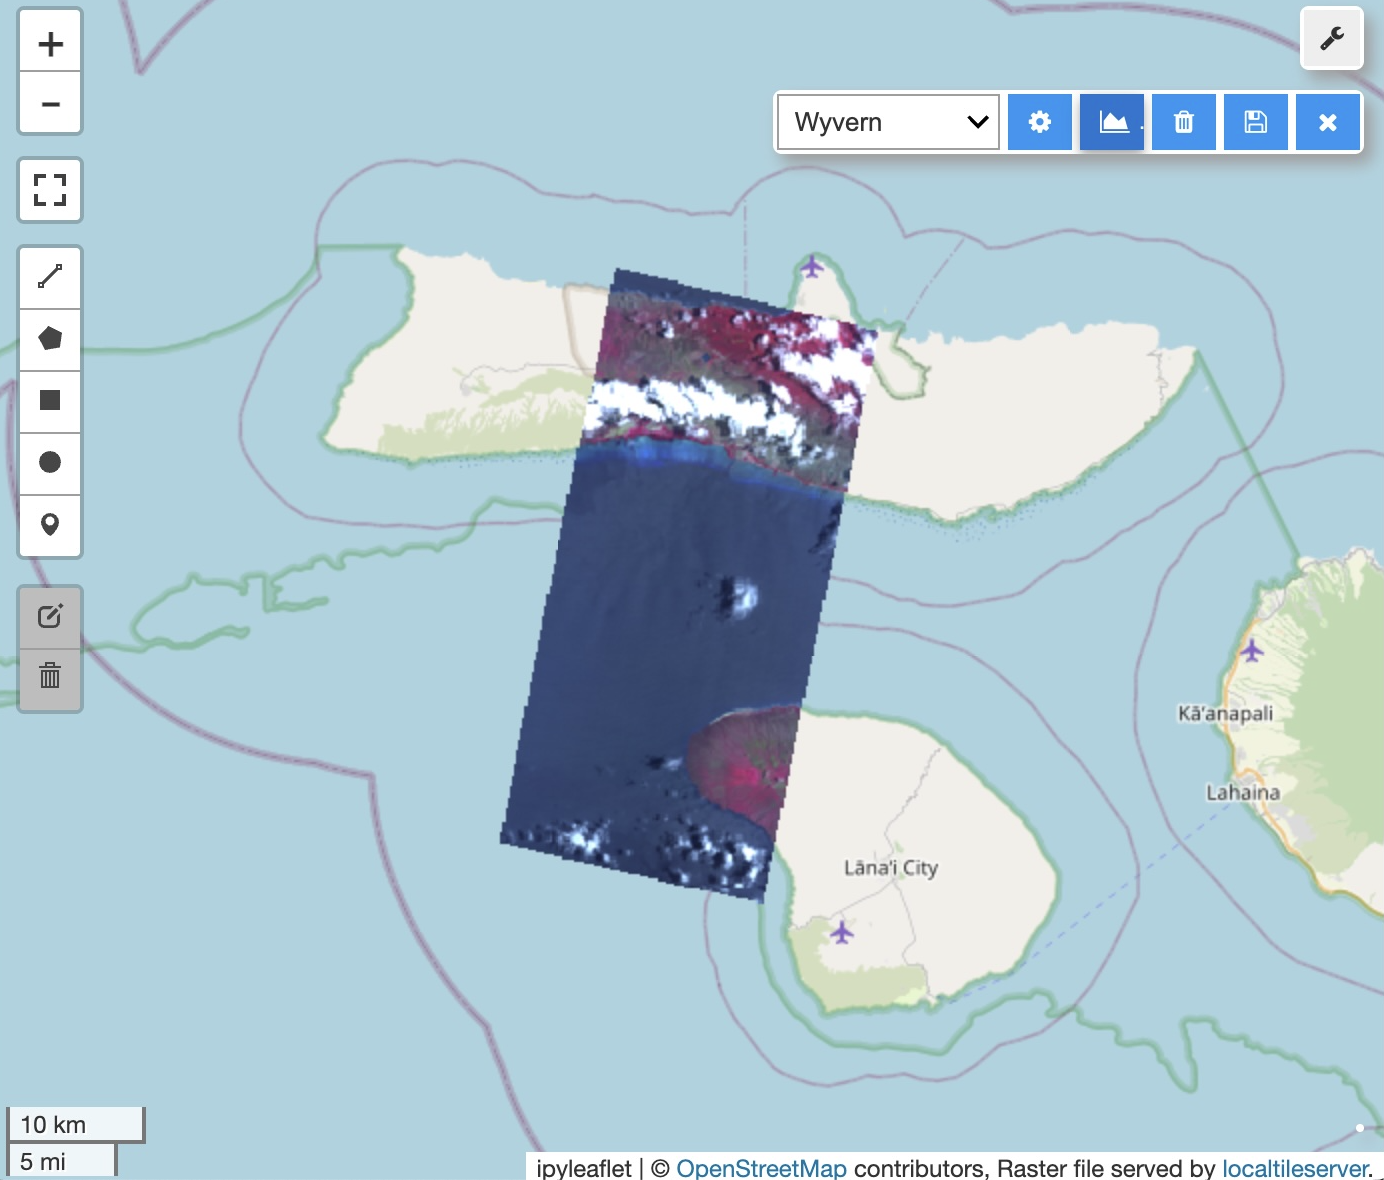

## Create a rectangular grid of Wyvern data

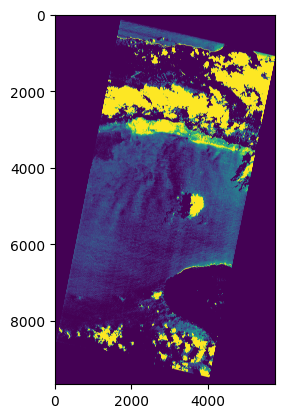

In [9]:
import numpy as np
import matplotlib.pyplot as plt
plt.imshow(np.clip(dataset['toa_radiance'][5],60,80))


In [10]:
gridded = hypercoast.grid_wyvern(dataset, row_range=(1400, 2200), col_range=(1400, 2200))
gridded = (gridded / 100).clip(0, 1)
gridded

<xarray.Dataset> Size: 90MB
Dimensions:       (y: 800, x: 800, wavelength: 31)
Coordinates:
  * y             (y) int64 6kB 0 1 2 3 4 5 6 7 ... 793 794 795 796 797 798 799
  * x             (x) int64 6kB 0 1 2 3 4 5 6 7 ... 793 794 795 796 797 798 799
  * wavelength    (wavelength) float64 248B 445.0 464.0 480.0 ... 849.0 869.0
    latitude      (y, x) float64 5MB 21.16 21.16 21.16 ... 21.12 21.12 21.12
    longitude     (y, x) float64 5MB -157.1 -157.1 -157.1 ... -157.1 -157.1
Data variables:
    toa_radiance  (y, x, wavelength) float32 79MB 0.0 0.0 0.0 ... 1.0 1.0 1.0

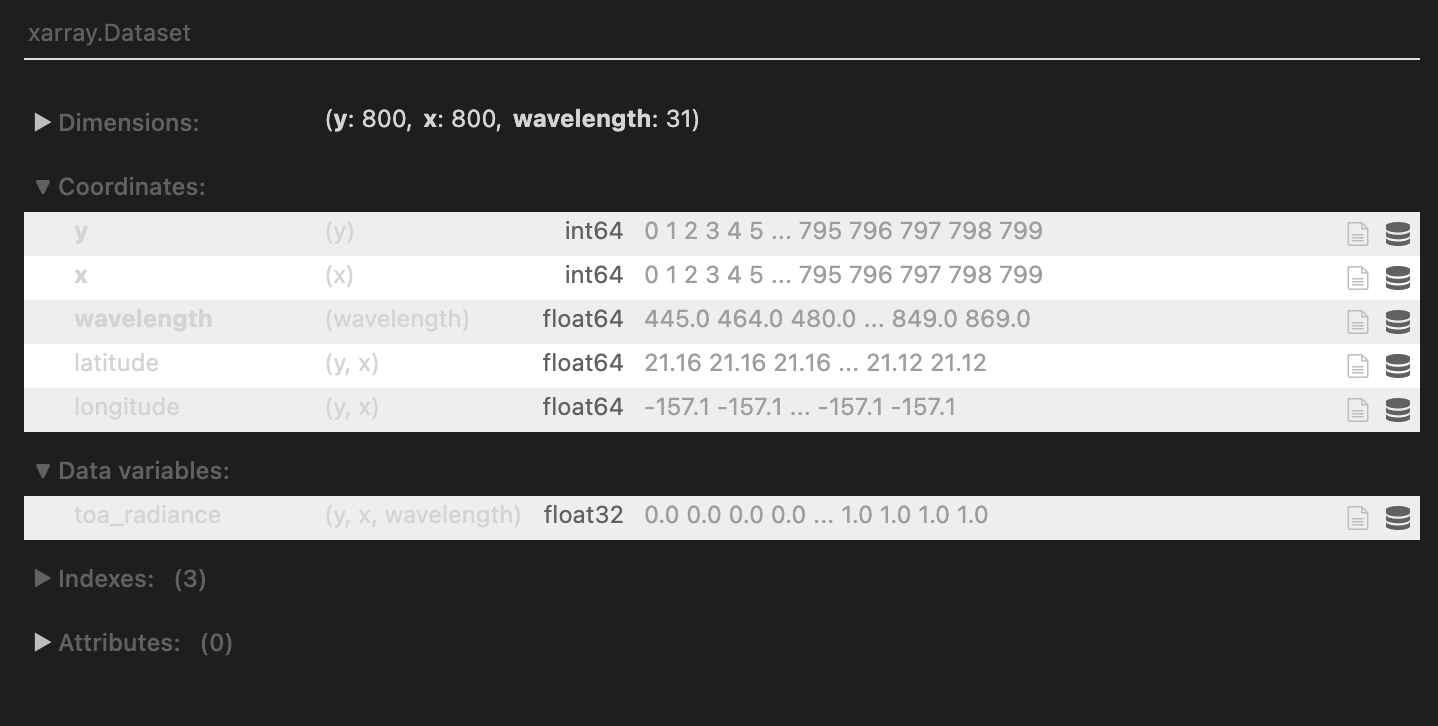

In [11]:
gridded.wavelength

<xarray.DataArray 'wavelength' (wavelength: 31)> Size: 248B
array([445., 464., 480., 490., 503., 510., 519., 534., 550., 569., 585., 600.,
       614., 634., 650., 659., 669., 679., 689., 700., 712., 722., 734., 749.,
       764., 781., 799., 814., 832., 849., 869.])
Coordinates:
  * wavelength  (wavelength) float64 248B 445.0 464.0 480.0 ... 849.0 869.0

## Create a 3D image cube

In [16]:
p = hypercoast.image_cube(
    gridded,
    variable="toa_radiance",
    cmap="jet",
    clim=(0, 1),
    rgb_wavelengths=[712, 534, 490],
    title="Radiance * 100",
)
p.show()

Widget(value='<iframe src="http://localhost:60907/index.html?ui=P_0x150626fd0_4&reconnect=auto" class="pyvista…

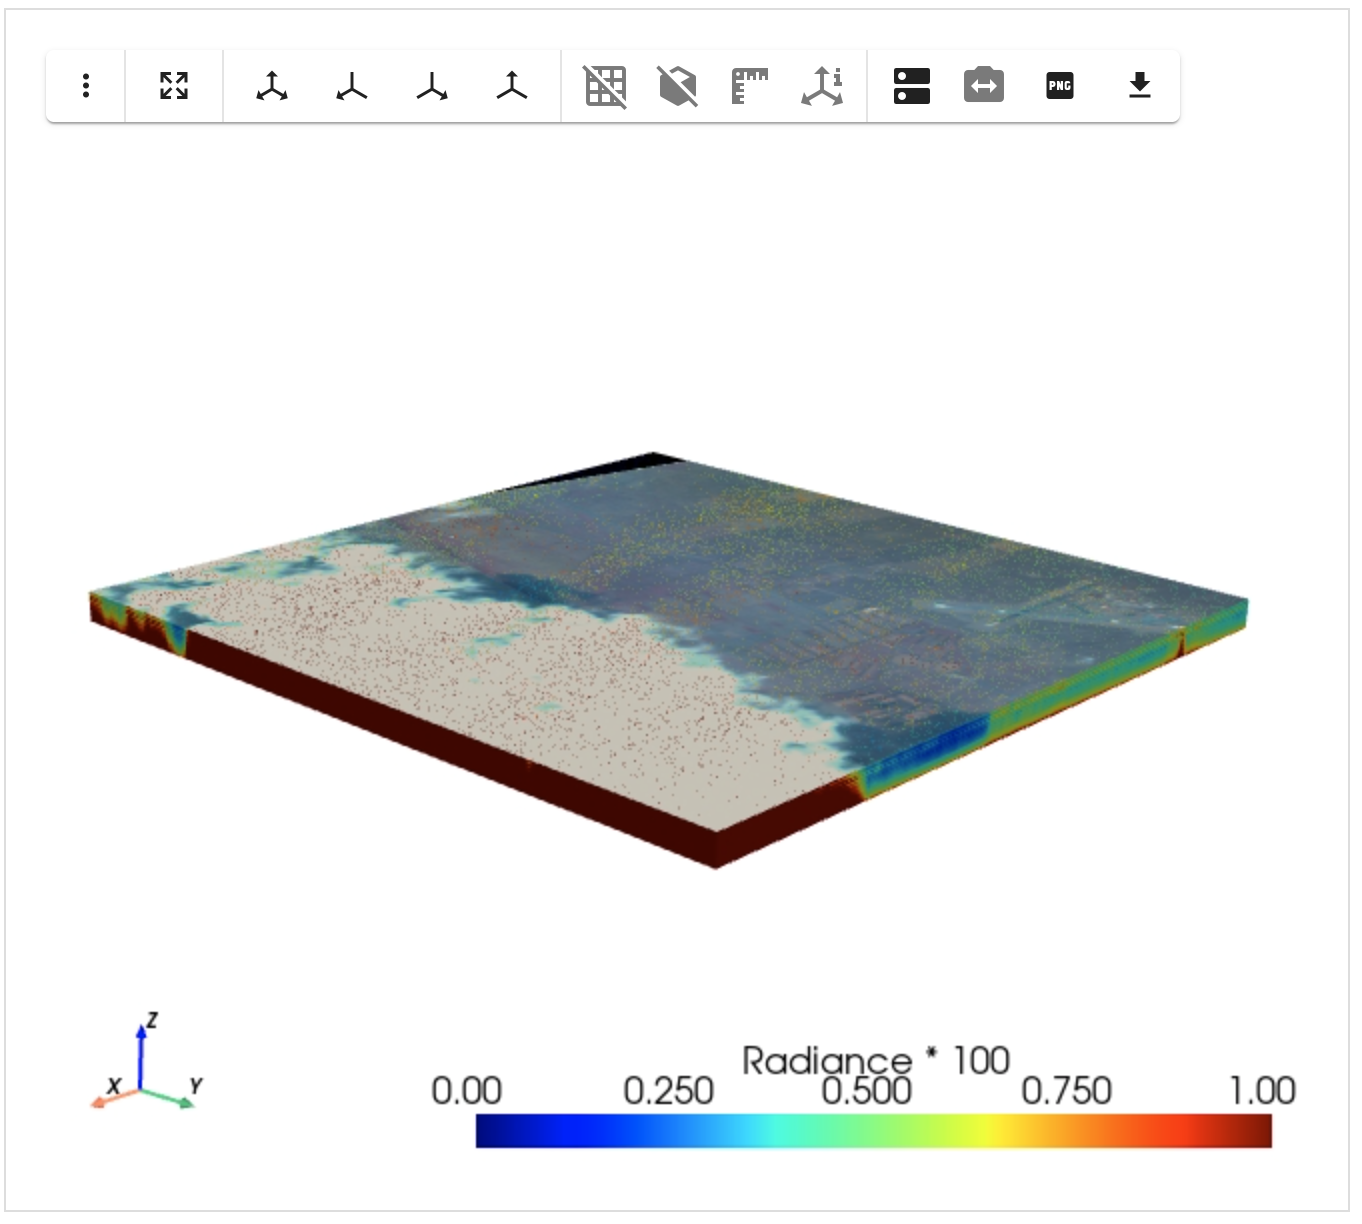

## Interactive slicing along the z-axis (band)

In [17]:
p = hypercoast.image_cube(
    gridded,
    variable="toa_radiance",
    cmap="jet",
    clim=(0, 1),
    rgb_wavelengths=[764, 634, 569],
    title="Radiance * 100",
    widget="slice",
)
p.add_text("Band slicing ", position="upper_right", font_size=14)
p.show()

Widget(value='<iframe src="http://localhost:60907/index.html?ui=P_0x4cc6b9590_5&reconnect=auto" class="pyvista…

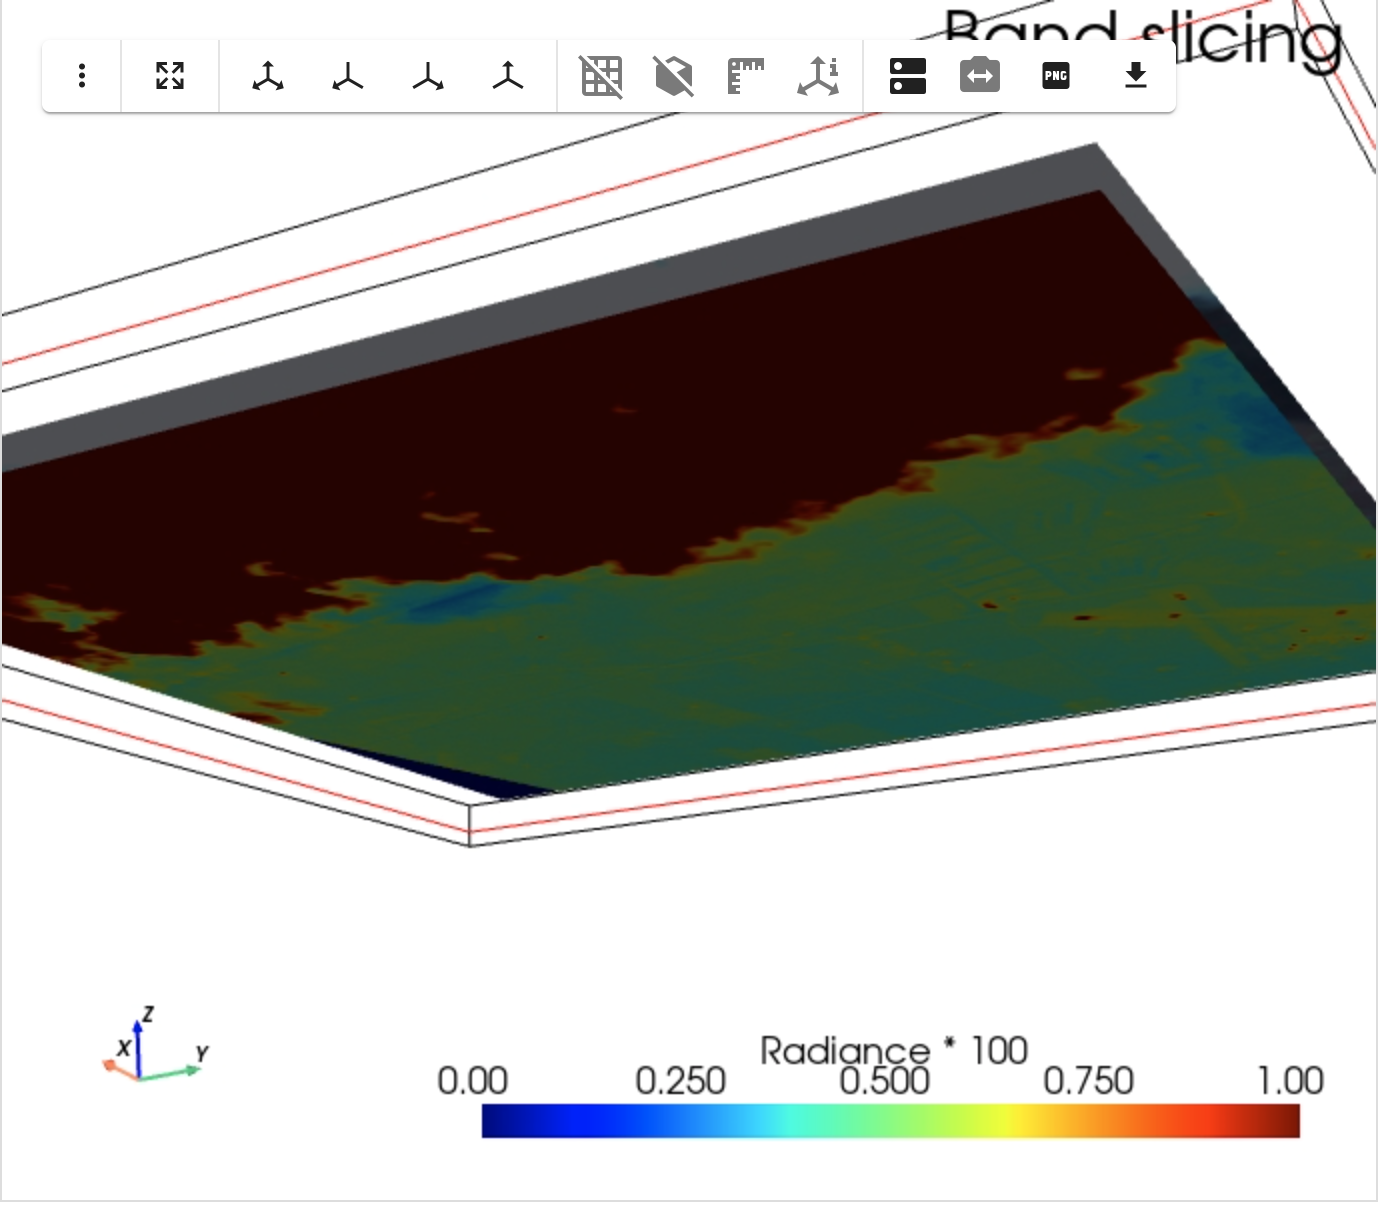

## Interactive slicing along the x-axis (longitude).

In [18]:
p = hypercoast.image_cube(
    gridded,
    variable="toa_radiance",
    cmap="jet",
    clim=(0, 1),
    rgb_wavelengths=[764, 634, 569],
    widget="slice",
    normal="x",
)
p.add_text("X-axis slicing ", position="upper_right", font_size=14)
p.show()

Widget(value='<iframe src="http://localhost:60907/index.html?ui=P_0x4cc6ba710_6&reconnect=auto" class="pyvista…

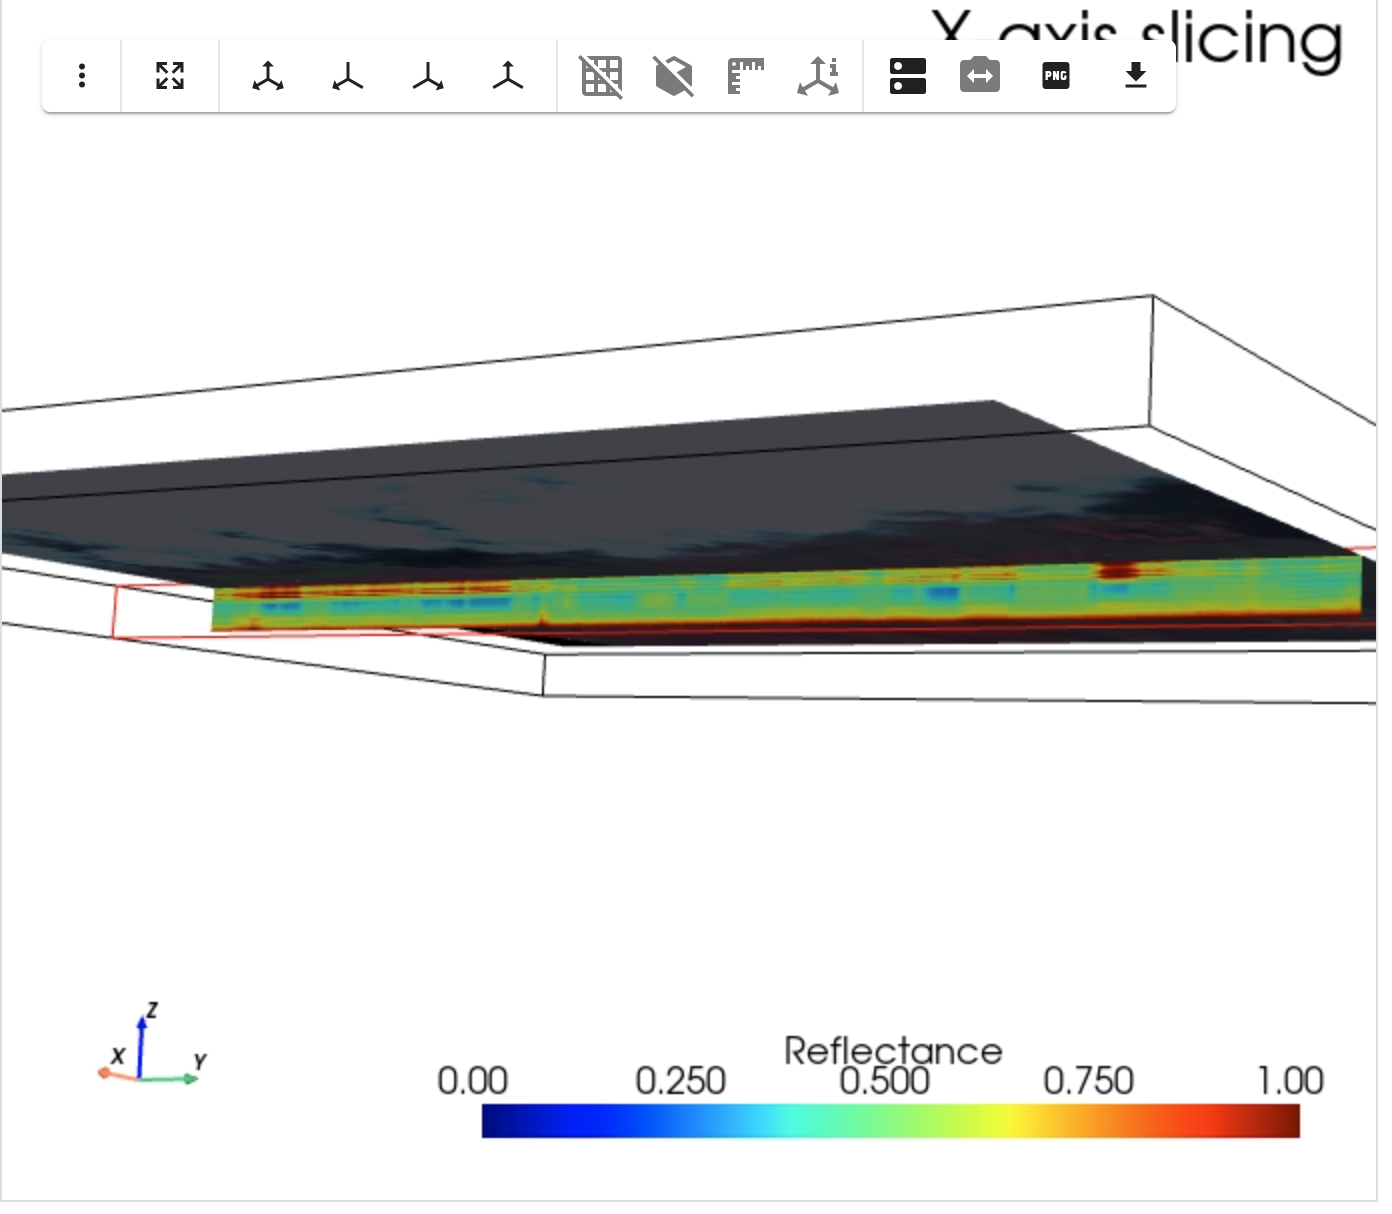

## Orthogonal slicing

In [19]:
p = hypercoast.image_cube(
    gridded,
    variable="toa_radiance",
    cmap="jet",
    clim=(0, 1),
    rgb_wavelengths=[764, 634, 569],
    title="Radiance * 100",
    widget="orthogonal",
)
p.add_text("Orthogonal slicing", position="upper_right", font_size=14)
p.show()

Widget(value='<iframe src="http://localhost:60907/index.html?ui=P_0x50ec88550_7&reconnect=auto" class="pyvista…

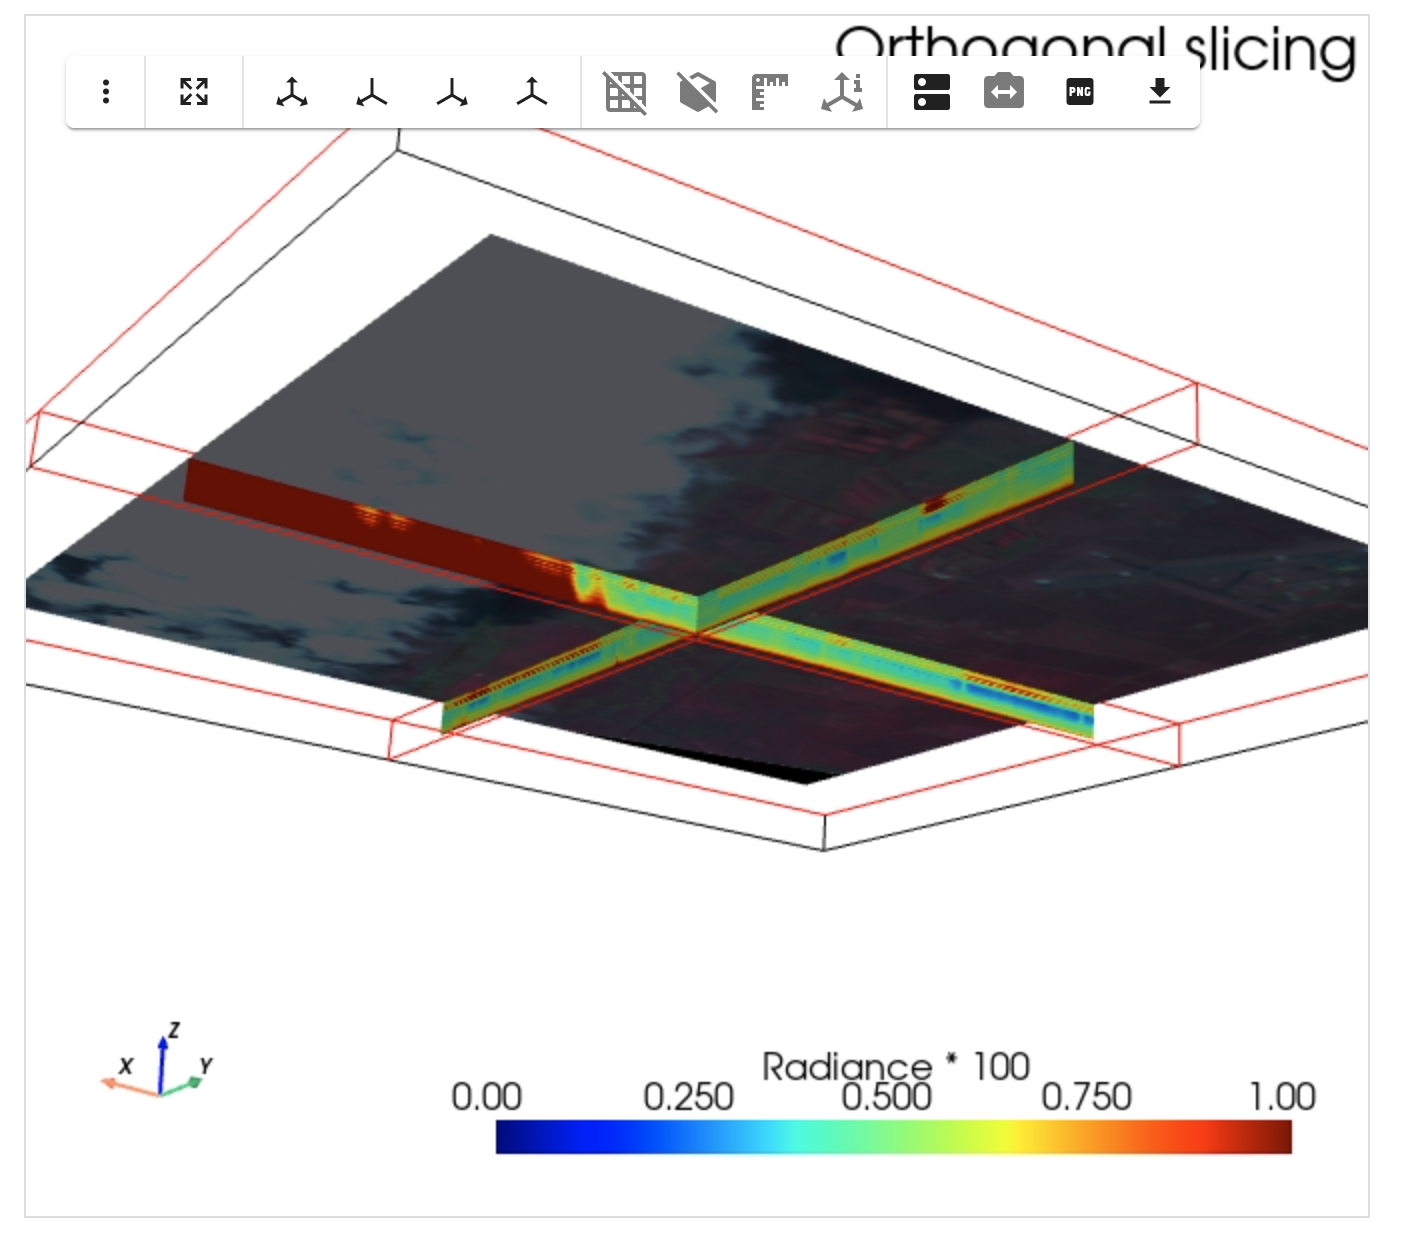

## Clip the image cube with a plane (band slicing)

In [21]:
p = hypercoast.image_cube(
    gridded,
    variable="toa_radiance",
    cmap="jet",
    clim=(0, 1),
    rgb_wavelengths=[764, 634, 569],
    title="Radiance * 100",
    widget="plane",
)
p.add_text("Band slicing", position="upper_right", font_size=14)
p.show()

Widget(value='<iframe src="http://localhost:60907/index.html?ui=P_0x150625f90_9&reconnect=auto" class="pyvista…

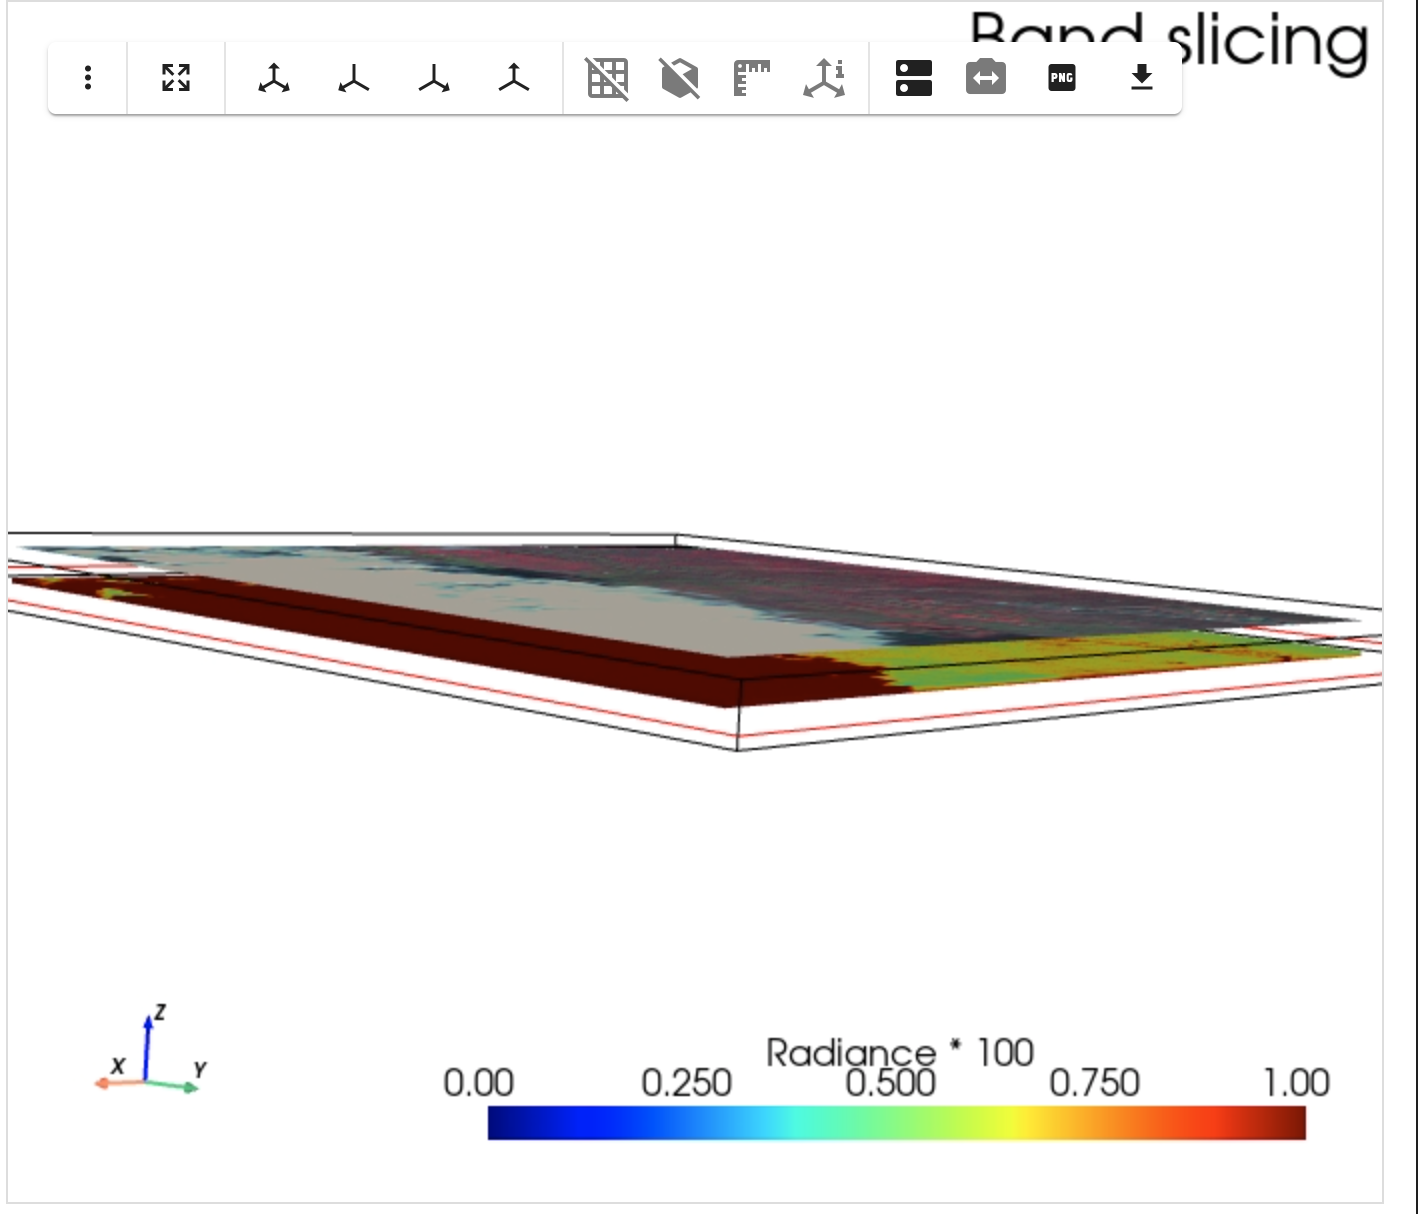

## Interactive thresholding

In [20]:
p = hypercoast.image_cube(
    gridded,
    variable="toa_radiance",
    cmap="jet",
    clim=(0, 1),
    rgb_wavelengths=[764, 634, 569],
    title="Radiance * 100",
    widget="threshold",
)
p.add_text("Thresholding", position="upper_right", font_size=14)
p.show()

Widget(value='<iframe src="http://localhost:60907/index.html?ui=P_0x50ec887d0_8&reconnect=auto" class="pyvista…

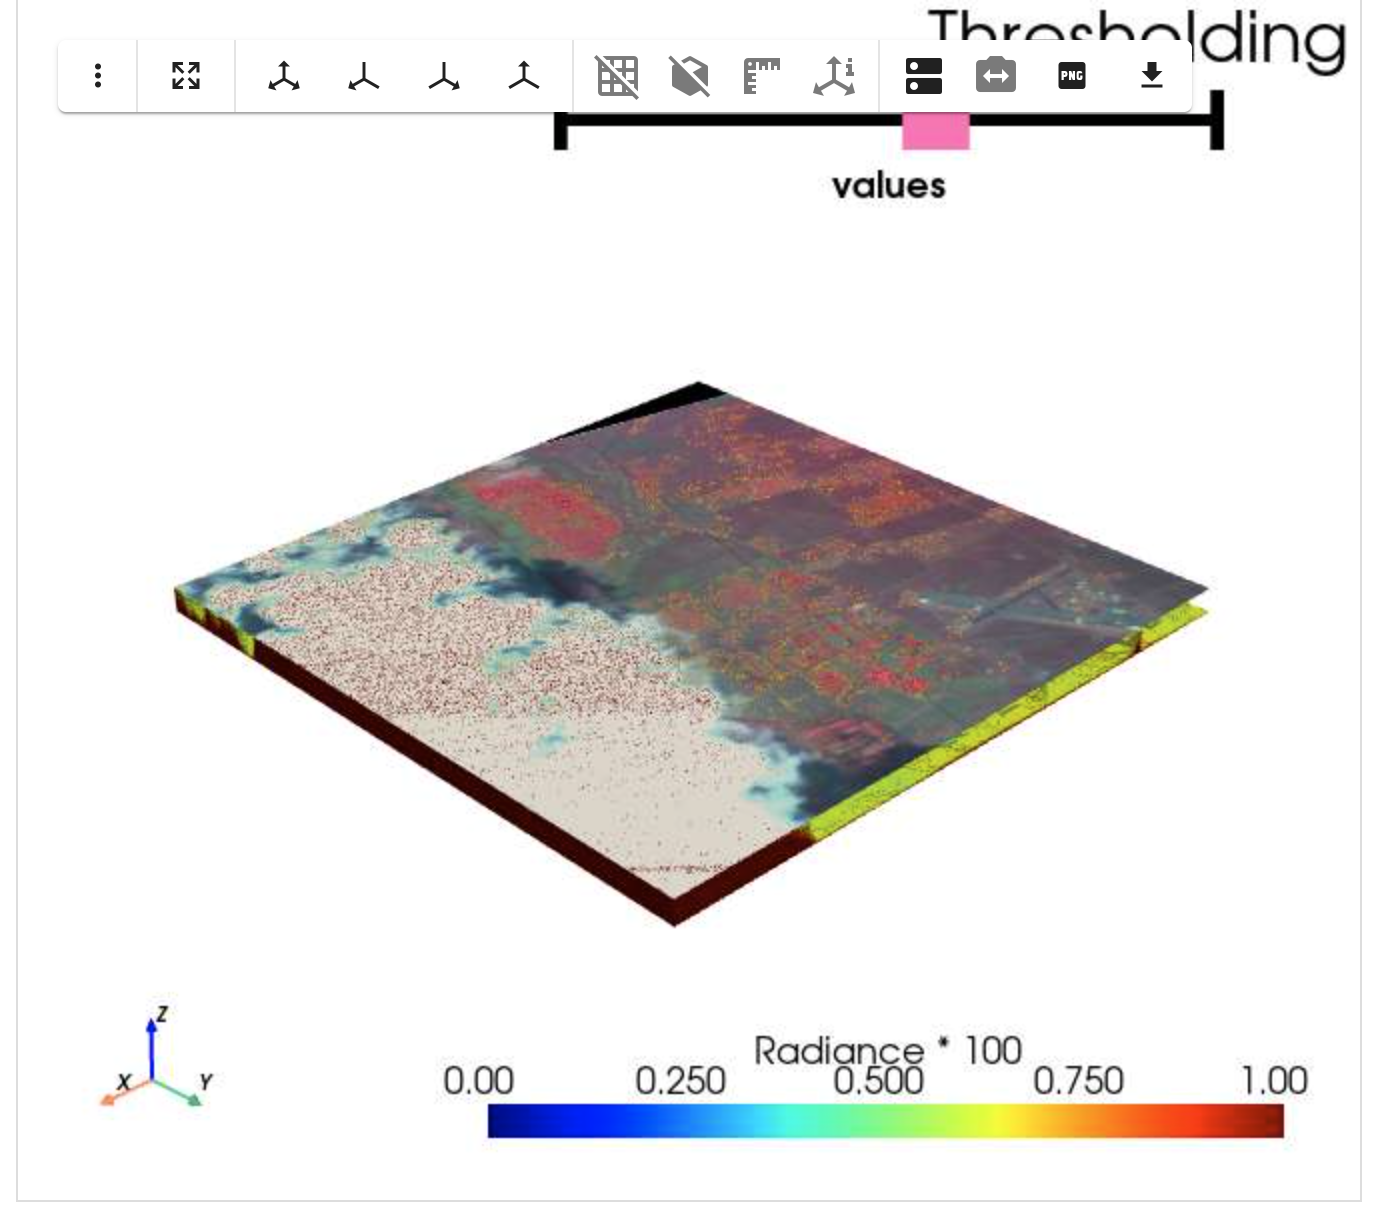